#### Section 1 → Setup & Load the Data
#### Section 2 → First Look (shape, head, info, dtypes)
#### Section 3 → Missing Values Audit
#### Section 4 → Univariate Analysis (distributions of individual features)
#### Section 5 → Bivariate Analysis (features vs Survived)
#### Section 6 → Correlation Heatmap
#### Section 7 → Outlier Detection
#### Section 8 → Feature Engineering Ideas
#### Section 9 → Summary of Findings

# Section 1 — Setup & Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#This shows the plots inside the nb
%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully 😄")

Libraries Loaded Successfully 😄


In [2]:
# --- LOAD DATA ---
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (891, 12)


###### Why load from a URL? The Titanic dataset is public and this URL always works. No setup needed.
###### Why check df.shape immediately? The very first thing any data scientist does after loading data is sanity-check that it actually loaded. shape gives you (rows, columns) — you should see (891, 12).

# Section 2 → First Look (shape, head, info, dtypes)

Section 2 is the most important habit you'll build as a data scientist — never touch data you haven't looked at first.

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [5]:
# Column names & data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


###### This is one of the most useful single commands in pandas. Run it and you'll see:

Every column name
How many non-null (non-missing) values it has
Its data type (int64, float64, object)

###### What to look for: Any column where the non-null count is less than 891 has missing values. Make a mental note of those — we'll audit them properly in Section 3.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


This gives you for every numeric column: count, mean, std, min, 25%, 50%, 75%, max.
What to look for as a beginner:

- Is min or max suspiciously extreme? (could be an outlier)
- Is mean very far from median (50%)? (could be a skewed distribution)
- Does the count match 891? If not, there are missing values in that column

In [7]:
# Check categorical columns
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [8]:
#  What do the categorical columns actually contain?
print(df['Survived'].value_counts())
print("---")
print(df['Pclass'].value_counts())
print("---")
print(df['Sex'].value_counts())
print("---")
print(df['Embarked'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
---
Sex
male      577
female    314
Name: count, dtype: int64
---
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


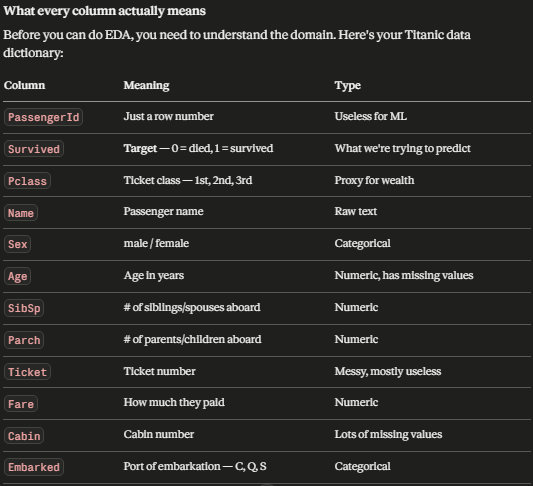

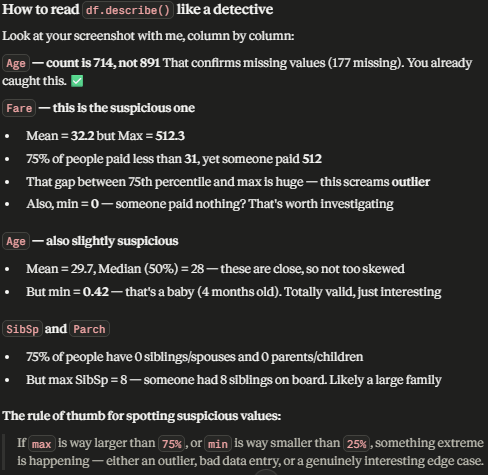

# Section 3 — Missing Values Audit
You identified Age, Cabin, Embarked. Now let's quantify exactly how bad each is.

In [9]:
# Cell 1 — Count missing values

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

          Missing Count  Missing %
Cabin               687  77.104377
Age                 177  19.865320
Embarked              2   0.224467


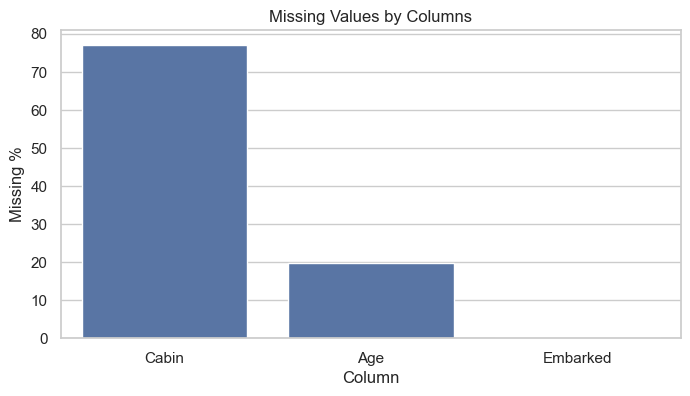

In [10]:
# Cell 2 — Visualize it

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df[missing_df['Missing Count'] > 0].index,
           y = missing_df[missing_df['Missing Count'] > 0]['Missing %'])
plt.title("Missing Values by Columns")
plt.ylabel("Missing %")
plt.xlabel('Column')
plt.show()

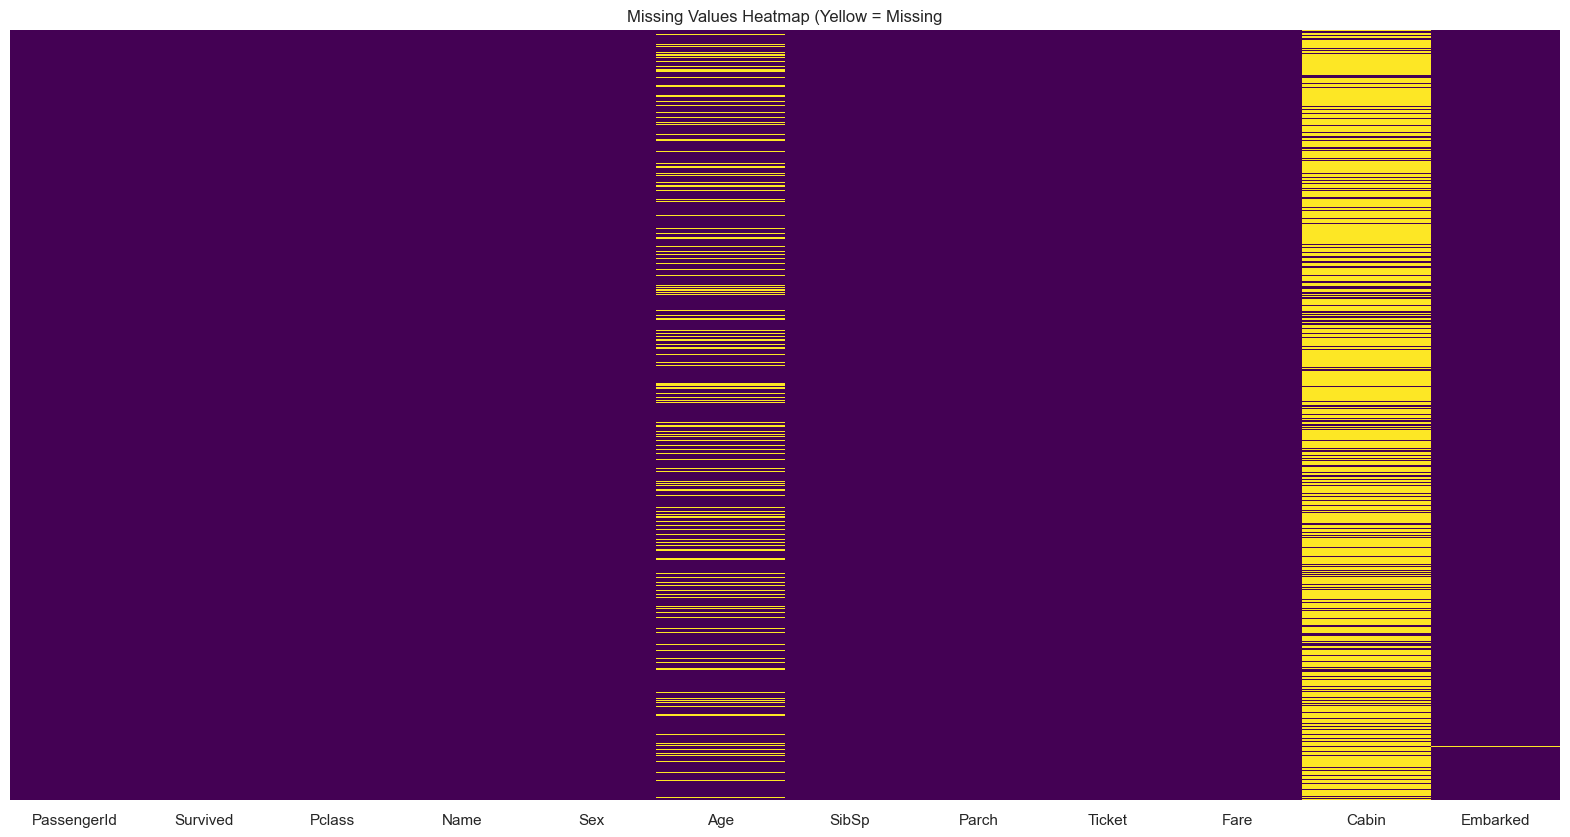

In [11]:
# Cell 3 — Heatmap of missingness

plt.figure(figsize=(20, 10))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing')
plt.show()

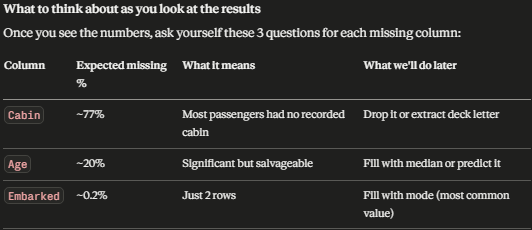

### MCAR vs MAR — explained simply
There are 3 types of missingness in the real world:
###### MCAR — Missing Completely At Random
- The data is missing for no reason related to anything else. Like if someone accidentally spilled coffee on 177 rows of a paper ledger. The missingness has no pattern — it's pure chance.
###### MAR — Missing At Random (badly named — it's actually not random)
- The data is missing, but the missingness is related to another column you can see. For example: maybe 3rd class passengers were less likely to have their age recorded because crew didn't bother. The age is missing, but why it's missing depends on Pclass.
###### MNAR — Missing Not At Random
- The missingness is related to the value itself. Example: very old or very young people might have hidden their age on purpose. The age is missing because of what the age would have been.

### Now let's look at YOUR heatmap with this framework
###### Age — scattered yellow lines, spread throughout
- This looks MCAR at first glance — your instinct was right. But to be sure, a real data scientist would check: do wealthier passengers (Pclass 1) have fewer missing ages? We'll actually test this in Section 5.
###### Cabin — almost entirely yellow, ~77% missing
- This is almost certainly MAR. Think about it logically — 1st class passengers had assigned cabins, 3rd class passengers were in shared berths with no cabin number. The missingness likely correlates strongly with Pclass. This isn't random at all.
###### Embarked — just 2 tiny yellow dots at the very bottom
- Only 2 rows. Basically ignorable. Probably just MCAR — two records were never filled in.

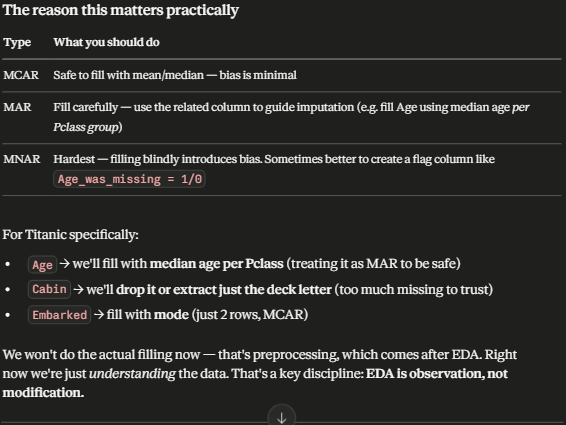

# Section 3 is done. You now know:

- Exactly what's missing and how much
- Why it's missing (the concept behind it)
- What you'd do about it later

# Section 4 — Univariate Analysis
Univariate = one variable at a time. The goal is simple: understand the distribution of each feature individually before you start comparing features against each other.

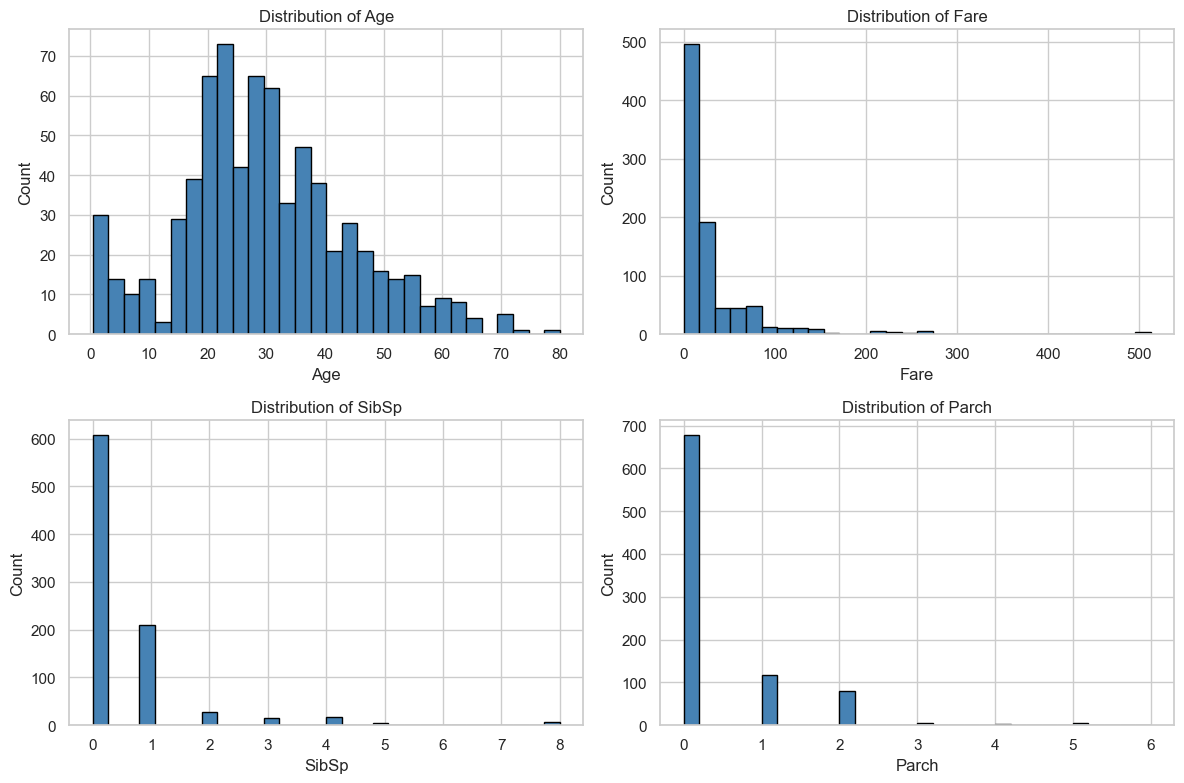

In [12]:
# Cell 1 — Distribution of numeric columns

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

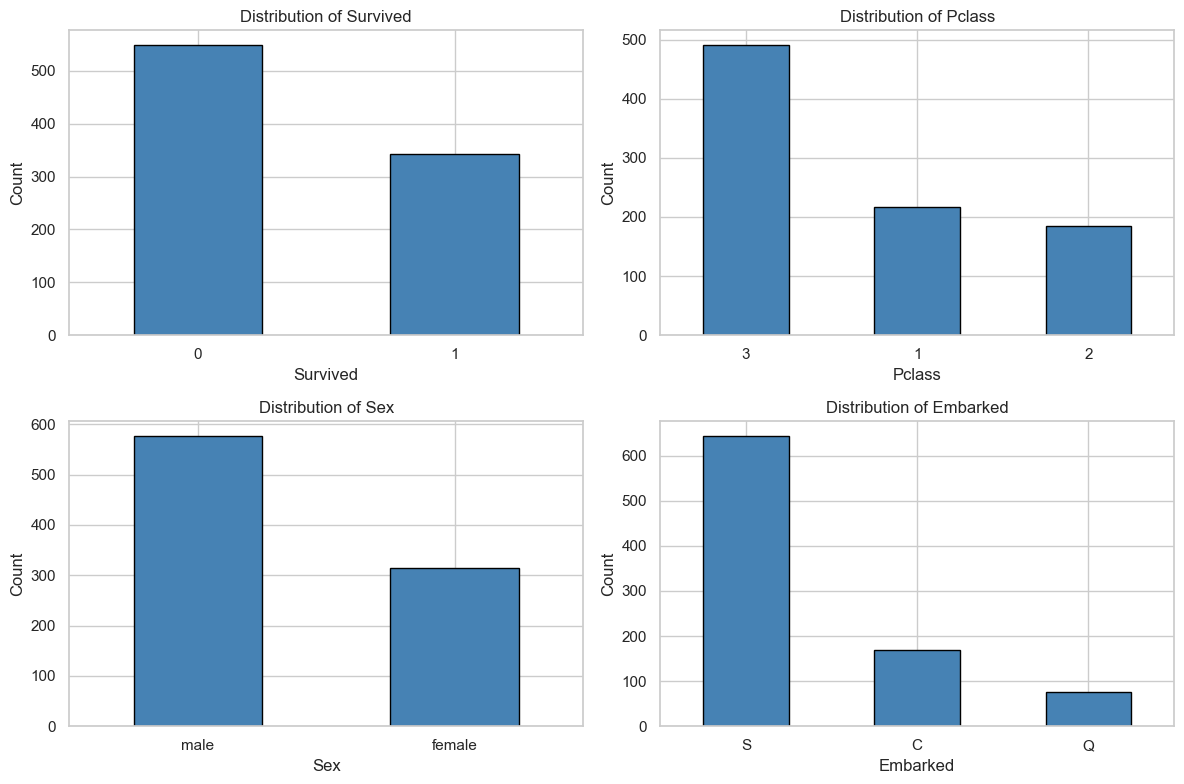

In [13]:
# Cell 2 — Distribution of categorical columns

cat_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Age — "Skewed, bulk 18-38" ✅
- Correct. It's slightly right-skewed — the tail goes towards older ages. The peak is around 20-30. This was a young crowd. Also notice that small bump near age 0-5 — children were definitely present.
#### Fare — "Right skewed" ✅ Perfect.
- This is the key insight: the histogram is almost a vertical wall on the left, then a long flat tail to the right. This means the vast majority paid cheap fares, but a tiny few paid astronomically more. That 512 max we saw? Look how isolated it is — one tiny bar all the way at the right edge. In ML, this kind of extreme skew can hurt models. We'd later apply a log transformation to compress that tail. File that away.
#### SibSp & Parch — "No idea" — let me explain
- Over 600 people had 0 siblings/spouses aboard. Over 600 had 0 parents/children aboard. What this tells you is: most Titanic passengers were travelling alone. This is actually a meaningful insight for survival — a person travelling alone behaves differently in a crisis than someone with family to protect or protect them. We'll see this pay off in Section 8 when we engineer a FamilySize feature.
Survived, Pclass, Sex, Embarked — all correct ✅

# The big picture insight from Section 4
- Before we even compare anything against survival, just from univariate analysis alone we already know:

#### The typical Titanic passenger was a young male, travelling alone in 3rd class, who boarded at Southampton and paid a cheap fare — and had a 38% chance of surviving.

That one sentence came entirely from reading 8 histograms. That's what univariate analysis is for.


# Section 5 — Bivariate Analysis (Features vs Survived)
This is where EDA gets exciting. We stop looking at features alone and start asking: which features actually separate survivors from non-survivors?

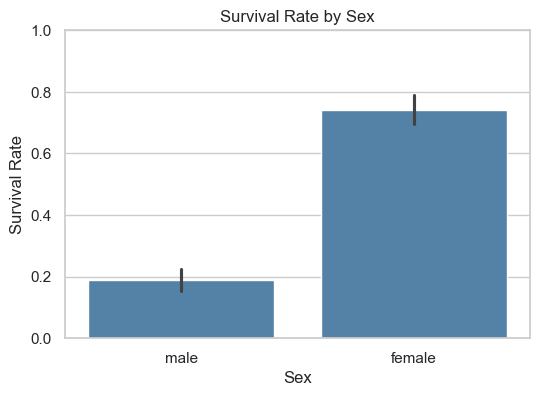

In [14]:
# Cell 1 — Survival rate by Sex

plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df, color='steelblue')
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

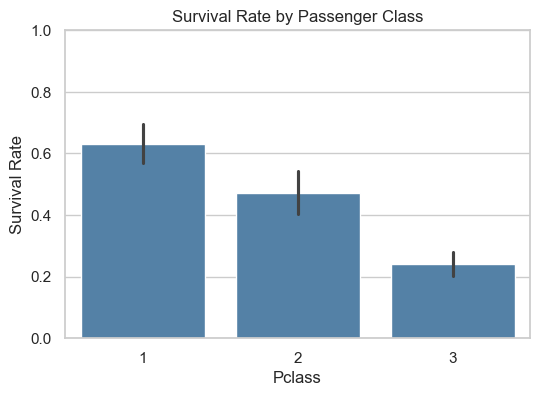

In [15]:
# Cell 2 — Survival rate by Pclass

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df, color='steelblue')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

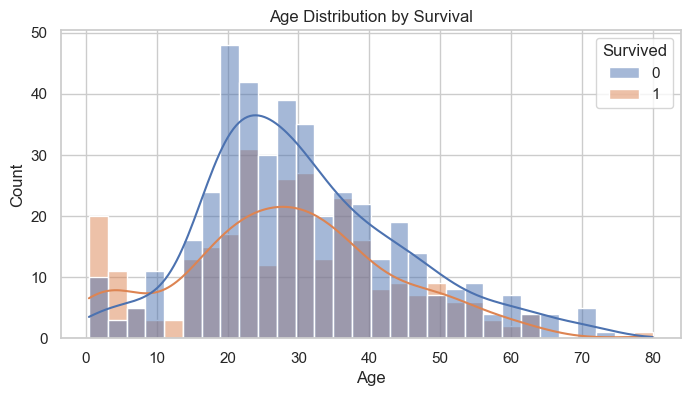

In [16]:
# Cell 3 — Age distribution: survivors vs non-survivors

plt.figure(figsize=(8, 4))
sns.histplot(df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

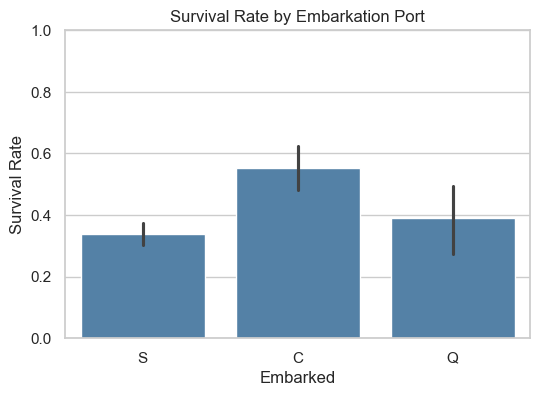

In [17]:
# Cell 4 — Survival rate by Embarked

plt.figure(figsize=(6, 4))
sns.barplot(x='Embarked', y='Survived', data=df, color='steelblue')
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

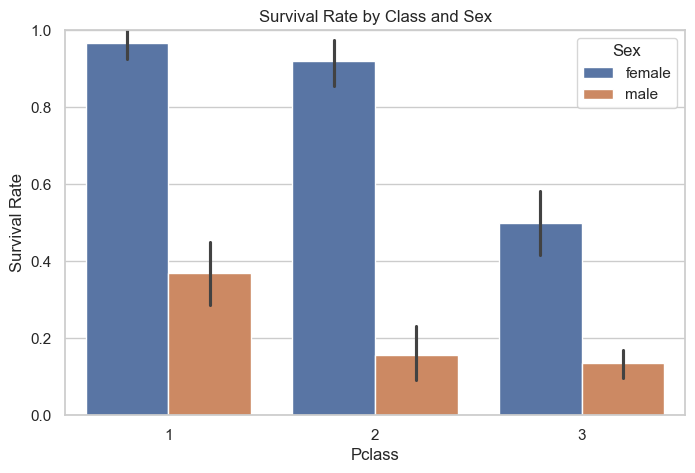

In [18]:
# Cell 5 — The most powerful plot: Sex + Pclass combined

plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival Rate by Class and Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

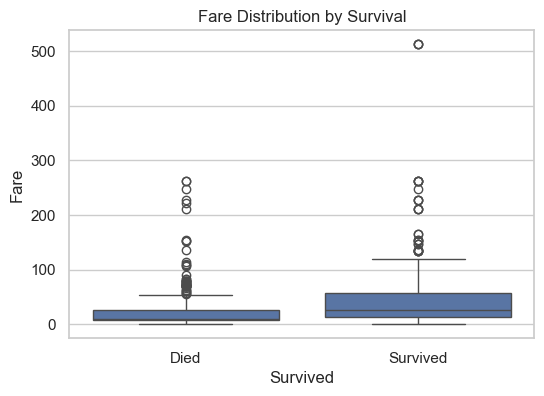

In [19]:
# Cell 6 — Fare vs Survival (box plot)

plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

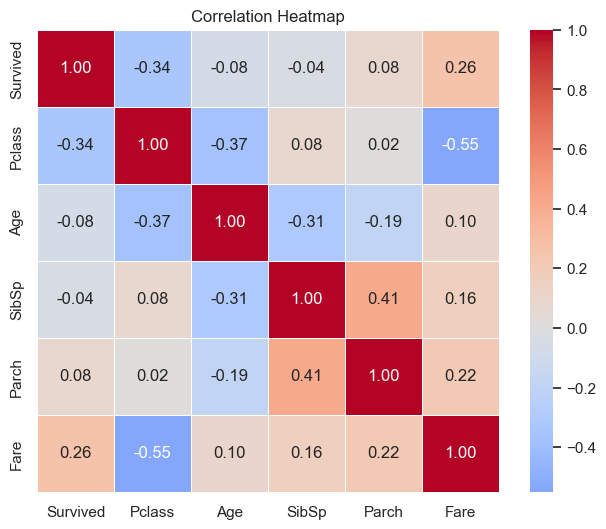

In [20]:
# Section 6 — Correlation Heatmap

plt.figure(figsize=(8, 6))
corr=df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

# The limitation of correlation — and why it matters
#### Correlation only measures linear numeric relationships. Notice what's missing from your heatmap: Sex is not there. Yet Sex was the strongest predictor you found in Section 5.
#### Why is it missing? Because Sex is categorical (male/female) — it's text, not a number. Correlation can't measure it directly.
#### This is a critical lesson: never rely on a heatmap alone to decide which features matter. The heatmap missed your best feature entirely. You need the bivariate plots from Section 5 and the heatmap together to get the full picture.
#### This is also why in Section 8 we'll encode Sex as 0/1 — so models can actually use it mathematically.

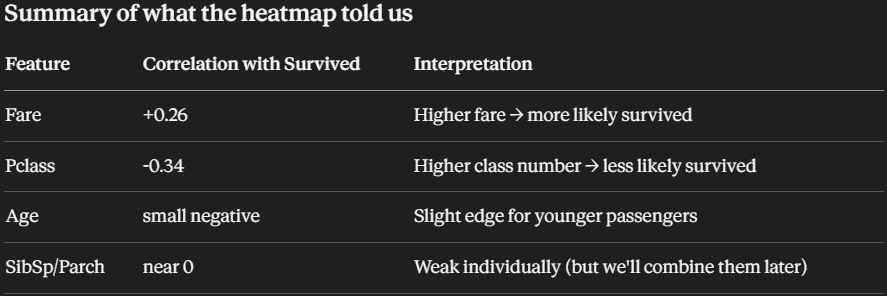

# Section 7 — Outlier Detection
We already suspected Fare has extreme outliers. Now we confirm it properly using box plots and a statistical rule.

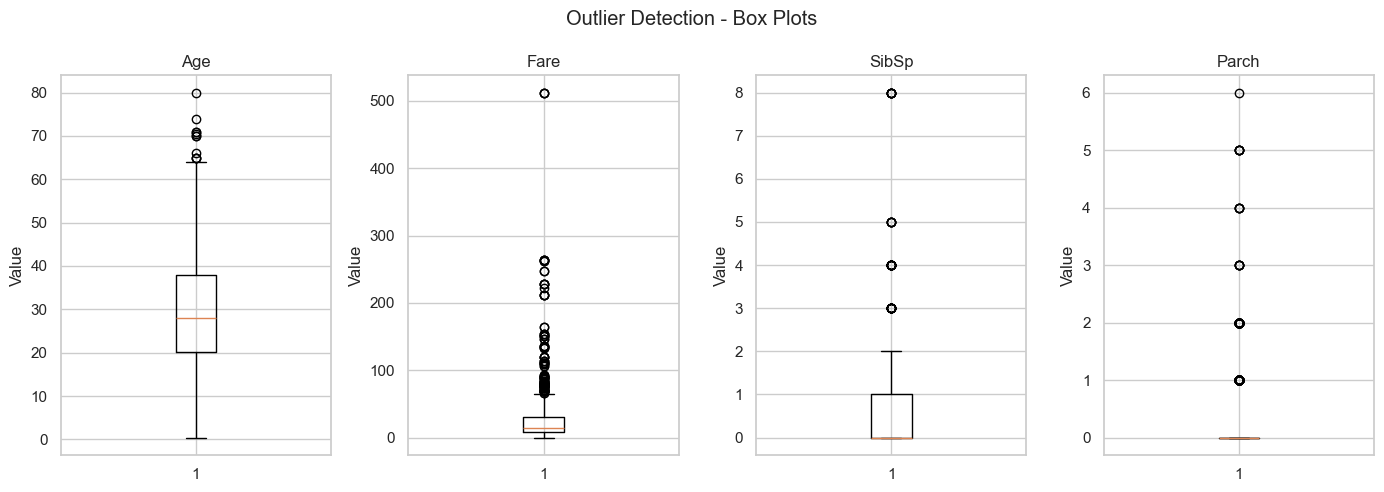

In [21]:
# Cell 1 — Box plots for all numeric features

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection - Box Plots')
plt.tight_layout()
plt.show()

In [22]:
# Cell 2 — The IQR rule (mathematical outlier detection)

def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")

for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    find_outliers(col)

Age: 11 outliers | Lower bound: -6.69 | Upper bound: 64.81
Fare: 116 outliers | Lower bound: -26.72 | Upper bound: 65.63
SibSp: 46 outliers | Lower bound: -1.50 | Upper bound: 2.50
Parch: 213 outliers | Lower bound: 0.00 | Upper bound: 0.00


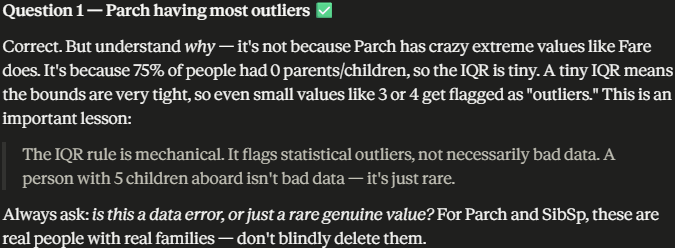
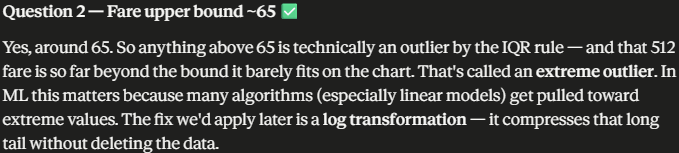
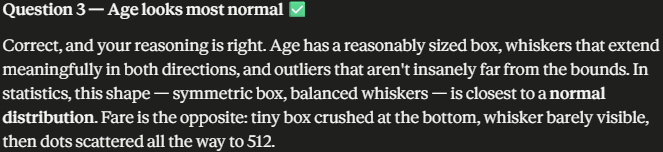
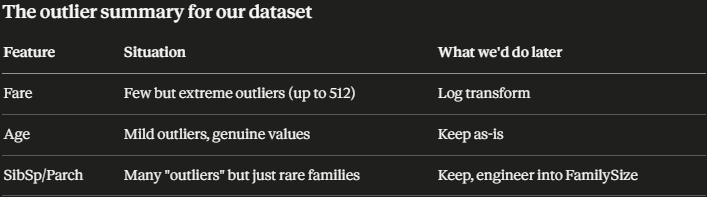

# Section 8 — Feature Engineering Ideas
#### This is where EDA pays off. Everything you've observed in the last 7 sections now turns into ideas for new features that could make a model smarter.
#### Feature engineering = creating new columns from existing ones that better capture the signal.

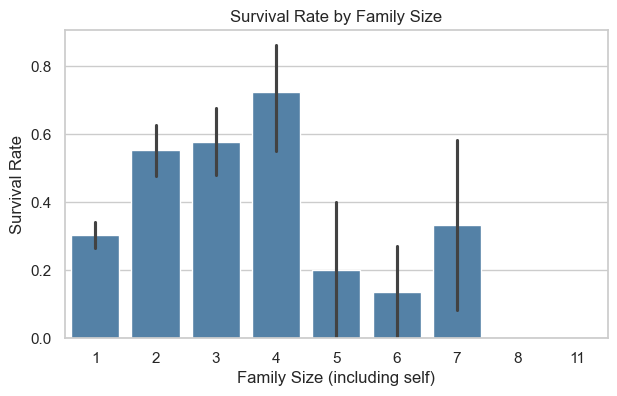

In [23]:
# Cell 1 — FamilySize

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="FamilySize", y='Survived', color='steelblue')
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.xlabel('Family Size (including self)')
plt.show()

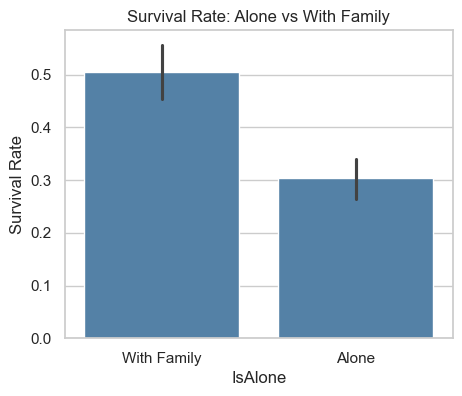

In [24]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='IsAlone', y='Survived', color='steelblue')
plt.title('Survival Rate: Alone vs With Family')
plt.xticks([0, 1], ['With Family', 'Alone'])
plt.ylabel('Survival Rate')
plt.show()

In [26]:
#Cell 3 — Title extracted from Name

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


Text(0.5, 1.0, 'Fare - Log(1+x)')

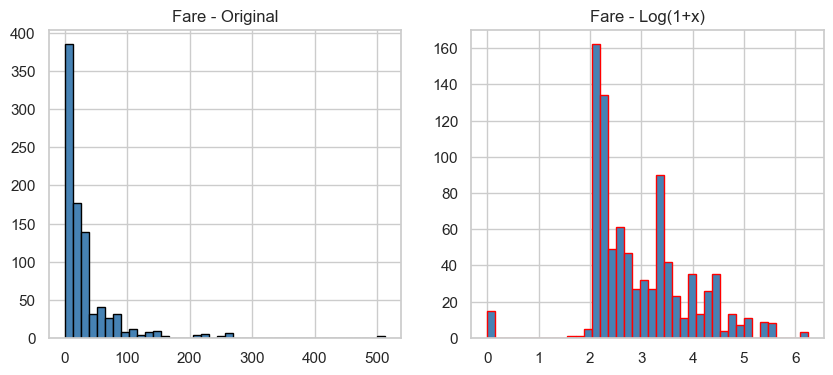

In [27]:
df['Fare_log'] = np.log1p(df['Fare'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['Fare'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title("Fare - Original")
axes[1].hist(df['Fare_log'], bins=40, color='steelblue', edgecolor='red')
axes[1].set_title("Fare - Log(1+x)")

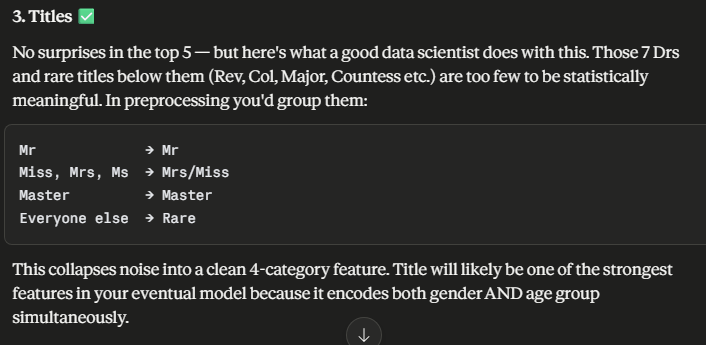

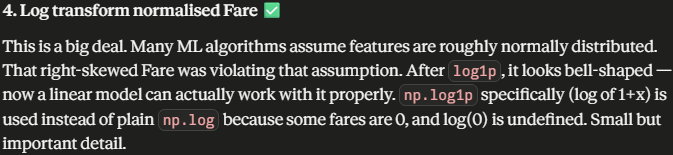

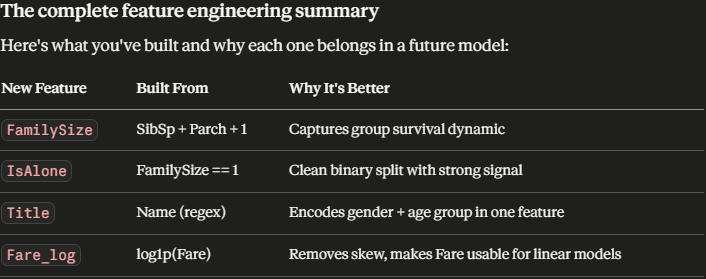

# Section 9 — EDA Summary
#### This is a habit every data scientist must build. After every EDA, you write a findings summary — not code, just clear sentences. This is what you'd present to a teammate or put at the top of a Kaggle notebook.

In [28]:
print("=== FINAL DATASET SNAPSHOT ===")
print(f"Total passengers: {len(df)}")
print(f"Survival rate: {df['Survived'].mean():.1%}")
print(f"\n--- Missing Values ---")
print(df[['Age','Cabin','Embarked']].isnull().sum())
print(f"\n--- New Features Created ---")
print(df[['FamilySize','IsAlone','Title','Fare_log']].head())

=== FINAL DATASET SNAPSHOT ===
Total passengers: 891
Survival rate: 38.4%

--- Missing Values ---
Age         177
Cabin       687
Embarked      2
dtype: int64

--- New Features Created ---
   FamilySize  IsAlone Title  Fare_log
0           2        0    Mr  2.110213
1           2        0   Mrs  4.280593
2           1        1  Miss  2.188856
3           2        0   Mrs  3.990834
4           1        1    Mr  2.202765


# ============================================
# TITANIC EDA — KEY FINDINGS
# ============================================

# DATASET
### - 891 passengers, 12 original features
### - Survival rate: 38.4% (baseline accuracy to beat)

# MISSING VALUES
### - Cabin: 77% missing → drop or extract deck letter
### - Age: 20% missing → impute with median per Pclass (MAR)
### - Embarked: 0.2% missing → fill with mode

# STRONGEST PREDICTORS FOUND
### 1. Sex — women survived at ~74%, men at ~19%
### 2. Pclass — 1st class: 63%, 2nd: 47%, 3rd: 24%
### 3. Fare — higher fare = higher survival (corr: +0.26)
### 4. Age — children had slightly better survival odds

# OUTLIERS
### - Fare has extreme outliers (max 512 vs upper bound ~65)
### - SibSp/Parch: many statistical outliers but genuine values

# FEATURE ENGINEERING IDEAS
### - FamilySize = SibSp + Parch + 1 (sweet spot: 2-4)
### - IsAlone = 1 if FamilySize == 1 (alone hurts survival)
### - Title extracted from Name (Mr/Mrs/Miss/Master/Rare)
### - Fare_log = log1p(Fare) to fix right skew

# NEXT STEPS (Preprocessing)
### - Encode Sex and Title as numbers
### - Impute Age using median per Pclass group
### - Drop Cabin or extract deck letter
### - Drop PassengerId, Name, Ticket (no signal)

# The EDA Checklist

1. Load & Sanity Check     → shape, head, tail, info
2. Missing Values Audit    → how much, which columns, why (MCAR/MAR/MNAR)
3. Univariate Analysis     → distributions of each feature individually
4. Bivariate Analysis      → each feature vs your target
5. Correlation Heatmap     → numeric relationships (remember its blind spot)
6. Outlier Detection       → IQR rule + box plots
7. Feature Engineering     → new columns that better capture signal
8. Write Findings Summary  → what you learned, what to do next